### Part 1) Unsupervised Learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
digits = load_digits()
x = digits.data
y = digits.target

In [3]:
isomap = Isomap(n_neighbors=10, n_components=2)
x_iso = isomap.fit_transform(x)

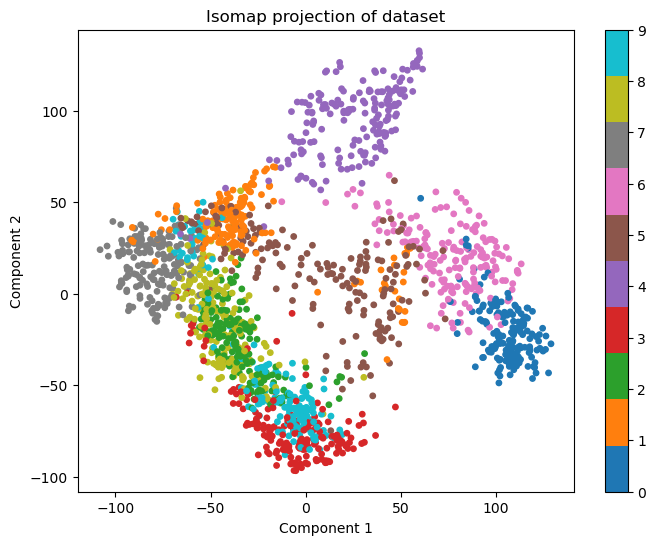

In [4]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(x_iso[:,0], x_iso[:,1], c=y, cmap='tab10', s=15)
plt.colorbar(scatter)
plt.title('Isomap projection of dataset')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

### Part 2) Supervised Learning

In [5]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

In [6]:
model = LogisticRegression(solver='sag', max_iter=5000)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,5000
,multi_class,'deprecated'


In [7]:
y_train_pred = model.predict(x_train)
y_val_pred = model.predict(x_val)

In [8]:
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

print(f'Training Accuracy: {train_acc:.4f}')
print(f'Validation Accuracy: {val_acc:.4f}')

Training Accuracy: 1.0000
Validation Accuracy: 0.9722


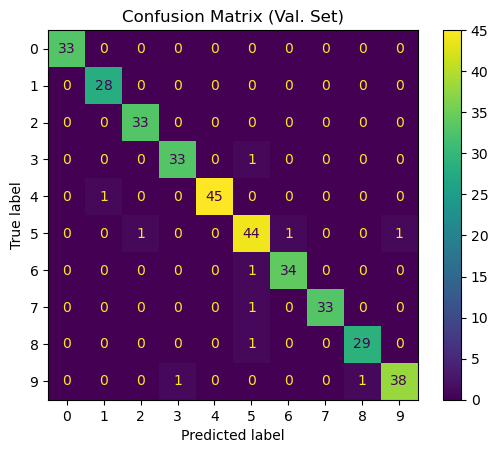

In [10]:
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix (Val. Set)')
plt.show()